<a href="https://colab.research.google.com/github/Loopinlogix/lesson5/blob/main/Lesson5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Assignment 5 - Titantic Data
Crystal MacNeil

Git and Githun Reposistory




In [16]:
import os

# Configure Git
!git config --global user.email "crystal_macneil@hotmail.com"
!git config --global user.name "Loopinlogix"

# Navigate to the correct repository directory if it exists
repo_dir = '/content/lesson5'
if os.path.exists(repo_dir):
    %cd {repo_dir}
    print(f"Navigated to {os.getcwd()}")
    !ls
else:
    print(f"Error: Repository directory {repo_dir} not found. Please ensure it is cloned correctly.")
!git clone https://github.com/Loopinlogix/lesson5.git
%cd /content/lesson4
!ls
!rm -rf /content/lesson5/lesson5
!ls /content/lesson5


/content/lesson5
Navigated to /content/lesson5
README.md
Cloning into 'lesson5'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.
Resolving deltas: 100% (1/1), done.
[Errno 2] No such file or directory: '/content/lesson4'
/content/lesson5
lesson5  README.md
README.md


##Import Dataset Exploratory Data Analysis

In [24]:
# Titanic Dataset Exploratory Data Analysis

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Task 1 Load dataset
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print()

Dataset loaded successfully!
Shape: (887, 8)



## Inspect Data

In [25]:
print("=" * 60)
print("TASK 2: INSPECT THE DATA")
print("=" * 60)

# Display the first 5 rows of the dataset
print("\n--- First 5 rows ---")
print(df.head())

# Display the last 5 rows of the dataset
print("\n--- Last 5 rows ---")
print(df.tail())

# Display the data types of each column
print("\n--- Data types ---")
print(df.dtypes)

# Display summary statistics of the numerical columns
print("\n--- Summary statistics ---")
print(df.describe())

TASK 2: INSPECT THE DATA

--- First 5 rows ---
   Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                        0  71.2833  
2  female  26.0                        0                        0   7.9250  
3  female  35.0                        1                        0  53.1000  
4    male  35.0                        0                        0   8.0500  

--- Last 5 rows ---
     Survived  Pclass    

##Clean and Preprocess data


In [28]:
print("\n" + "=" * 60)
print("TASK 3: CLEAN AND PREPROCESS THE DATA")
print("=" * 60)

# Create a new categorical feature 'PclassCategory' from 'Pclass'
df['PclassCategory'] = df['Pclass'].map({1: 'First', 2: 'Second', 3: 'Third'})
print("\n--- PclassCategory created ---")
print(df[['Pclass', 'PclassCategory']].head())

# Create a new categorical feature 'CabinCategory' from 'Cabin'

if 'Cabin' in df.columns:
    df['CabinCategory'] = df['Cabin'].apply(lambda x: 'Has Cabin' if pd.notna(x) and str(x).strip() != '' else 'No Cabin')
    print("\n--- CabinCategory created from 'Cabin' column ---")
else:
    print("\n--- Note: 'Cabin' column not found in this dataset ---")
    df['CabinCategory'] = 'No Cabin'

# Handle missing values in the 'Age' column (use mean age)
print(f"\n--- Missing ages before: {df['Age'].isna().sum()} ---")
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)
print(f"--- Missing ages after: {df['Age'].isna().sum()} ---")
print(f"--- Mean age used: {mean_age:.2f} ---")

# Create a 'Family' feature by combining 'Siblings/Spouses Aboard' and 'Parents/Children Aboard'
df['Family'] = df['Siblings/Spouses Aboard'] + df['Parents/Children Aboard']
print("\n--- Family feature created ---")
print(df[['Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Family']].head(10))


TASK 3: CLEAN AND PREPROCESS THE DATA

--- PclassCategory created ---
   Pclass PclassCategory
0       3          Third
1       1          First
2       3          Third
3       1          First
4       3          Third

--- Note: 'Cabin' column not found in this dataset ---

--- Missing ages before: 0 ---
--- Missing ages after: 0 ---
--- Mean age used: 29.47 ---

--- Family feature created ---
   Siblings/Spouses Aboard  Parents/Children Aboard  Family
0                        1                        0       1
1                        1                        0       1
2                        0                        0       0
3                        1                        0       1
4                        0                        0       0
5                        0                        0       0
6                        0                        0       0
7                        3                        1       4
8                        0                        2       2


##Identify Specific datapoints


In [29]:
print("\n" + "=" * 60)
print("TASK 4: IDENTIFY SPECIFIC DATA POINTS")
print("=" * 60)

# Find passengers with the highest fare
max_fare = df['Fare'].max()
highest_fare_passengers = df[df['Fare'] == max_fare]
print(f"\n--- Highest fare: ${max_fare:.2f} ---")
print(highest_fare_passengers[['Name', 'PclassCategory', 'Fare', 'Survived']])

# Find passengers with the largest family size
max_family = df['Family'].max()
largest_family_passengers = df[df['Family'] == max_family]
print(f"\n--- Largest family size: {max_family} ---")
print(largest_family_passengers[['Name', 'Sex', 'Age', 'Family', 'Survived']])


TASK 4: IDENTIFY SPECIFIC DATA POINTS

--- Highest fare: $512.33 ---
                                  Name PclassCategory      Fare  Survived
257                    Miss. Anna Ward          First  512.3292         1
676  Mr. Thomas Drake Martinez Cardeza          First  512.3292         1
733              Mr. Gustave J Lesurer          First  512.3292         1

--- Largest family size: 10 ---
                            Name     Sex   Age  Family  Survived
158    Master. Thomas Henry Sage    male   5.0      10         0
179  Miss. Constance Gladys Sage  female   8.0      10         0
200           Mr. Frederick Sage    male  17.0      10         0
322      Mr. George John Jr Sage    male  20.0      10         0
788       Miss. Stella Anna Sage  female  21.0      10         0
842      Mr. Douglas Bullen Sage    male  18.0      10         0
859     Miss. Dorothy Edith Sage  female  14.0      10         0


## Demonstrate Pandas Series and DataFrame functionalities

In [30]:
print("\n" + "=" * 60)
print("TASK 5: PANDAS SERIES AND DATAFRAME FUNCTIONALITIES")
print("=" * 60)

# Create a Pandas Series of passenger names
names_series = pd.Series(df['Name'].values, name='Passenger Names')
print("\n--- Pandas Series of passenger names (first 5) ---")
print(names_series.head())

# Create a DataFrame of passenger names and ages
names_ages_df = df[['Name', 'Age']].copy()
print("\n--- DataFrame of passenger names and ages (first 5) ---")
print(names_ages_df.head())

# Slice the DataFrame to show only passengers older than 50
older_passengers = names_ages_df[names_ages_df['Age'] > 50]
print(f"\n--- Passengers older than 50 ({len(older_passengers)} total) ---")
print(older_passengers.head(10))


TASK 5: PANDAS SERIES AND DATAFRAME FUNCTIONALITIES

--- Pandas Series of passenger names (first 5) ---
0                               Mr. Owen Harris Braund
1    Mrs. John Bradley (Florence Briggs Thayer) Cum...
2                                Miss. Laina Heikkinen
3          Mrs. Jacques Heath (Lily May Peel) Futrelle
4                              Mr. William Henry Allen
Name: Passenger Names, dtype: object

--- DataFrame of passenger names and ages (first 5) ---
                                                Name   Age
0                             Mr. Owen Harris Braund  22.0
1  Mrs. John Bradley (Florence Briggs Thayer) Cum...  38.0
2                              Miss. Laina Heikkinen  26.0
3        Mrs. Jacques Heath (Lily May Peel) Futrelle  35.0
4                            Mr. William Henry Allen  35.0

--- Passengers older than 50 (72 total) ---
                               Name   Age
6            Mr. Timothy J McCarthy  54.0
11          Miss. Elizabeth Bonnell  58.0
1

##Introduce Multi Indexing

In [31]:
print("\n" + "=" * 60)
print("TASK 6: MULTI-INDEXING")
print("=" * 60)

# Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
multi_index_df = df.groupby(['Sex', 'Pclass']).agg({
    'Survived': ['mean', 'sum', 'count'],
    'Age': 'mean',
    'Fare': 'mean',
    'Family': 'mean'
}).round(2)

multi_index_df.columns = ['Survival_Rate', 'Survivors', 'Total', 'Avg_Age', 'Avg_Fare', 'Avg_Family']
print("\n--- Multi-index DataFrame grouped by Sex and Pclass ---")
print(multi_index_df)


TASK 6: MULTI-INDEXING

--- Multi-index DataFrame grouped by Sex and Pclass ---
               Survival_Rate  Survivors  Total  Avg_Age  Avg_Fare  Avg_Family
Sex    Pclass                                                                
female 1                0.97         91     94    35.26    106.13        1.01
       2                0.92         70     76    28.98     21.97        1.09
       3                0.50         72    144    22.14     16.12        1.69
male   1                0.37         45    122    41.51     67.23        0.59
       2                0.16         17    108    30.49     19.74        0.56
       3                0.14         47    343    26.47     12.70        0.73


## Visualizations


TASK 7: VISUALIZATIONS


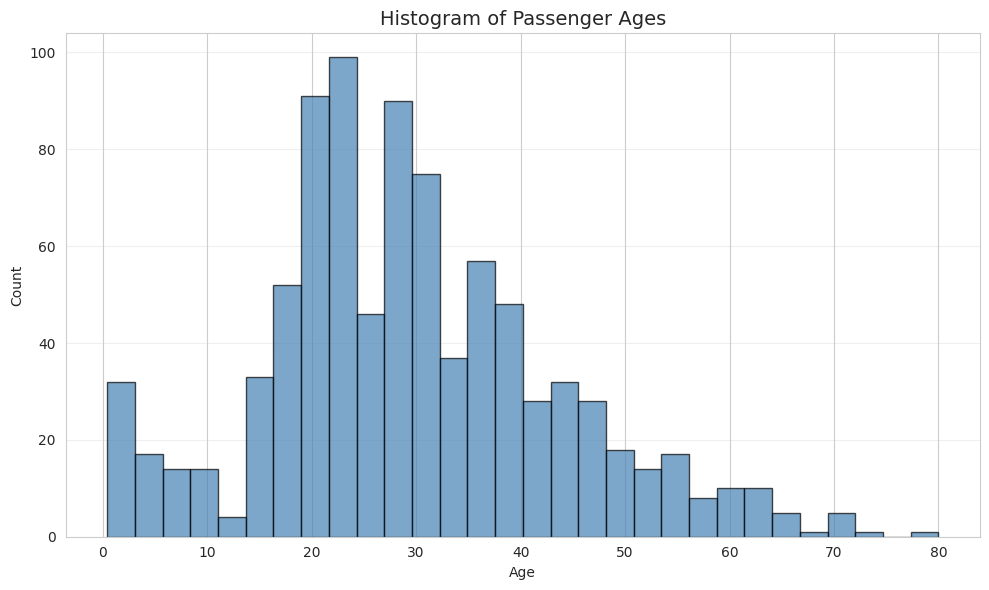

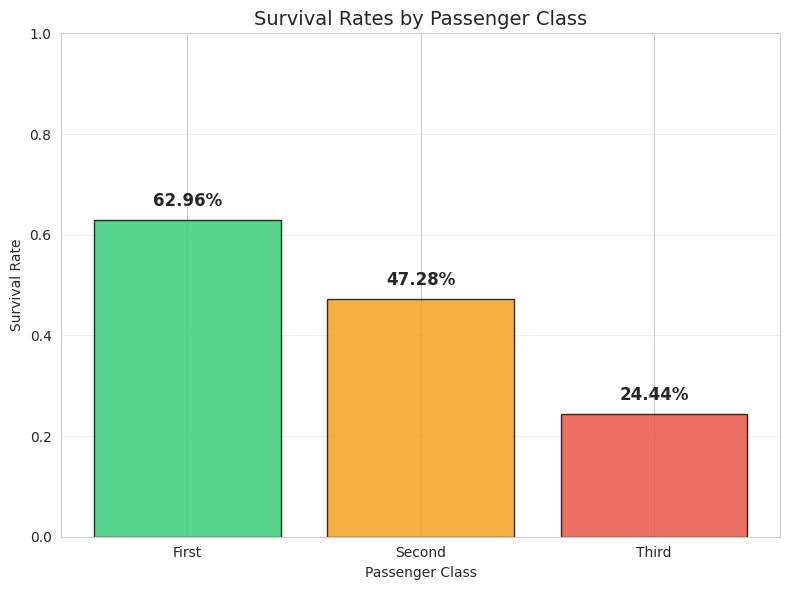

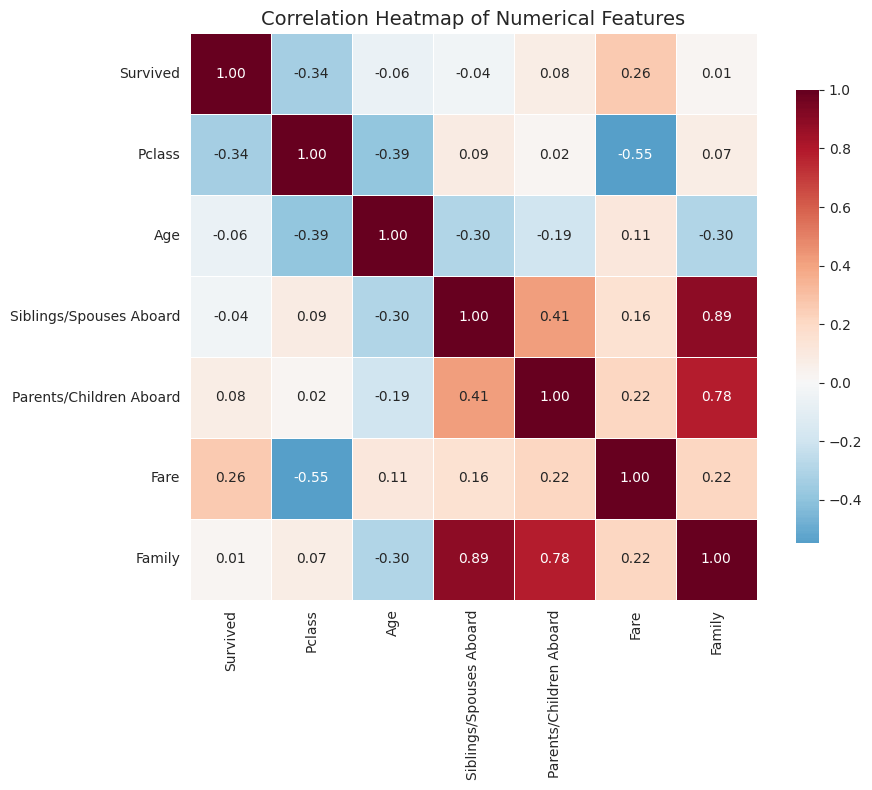

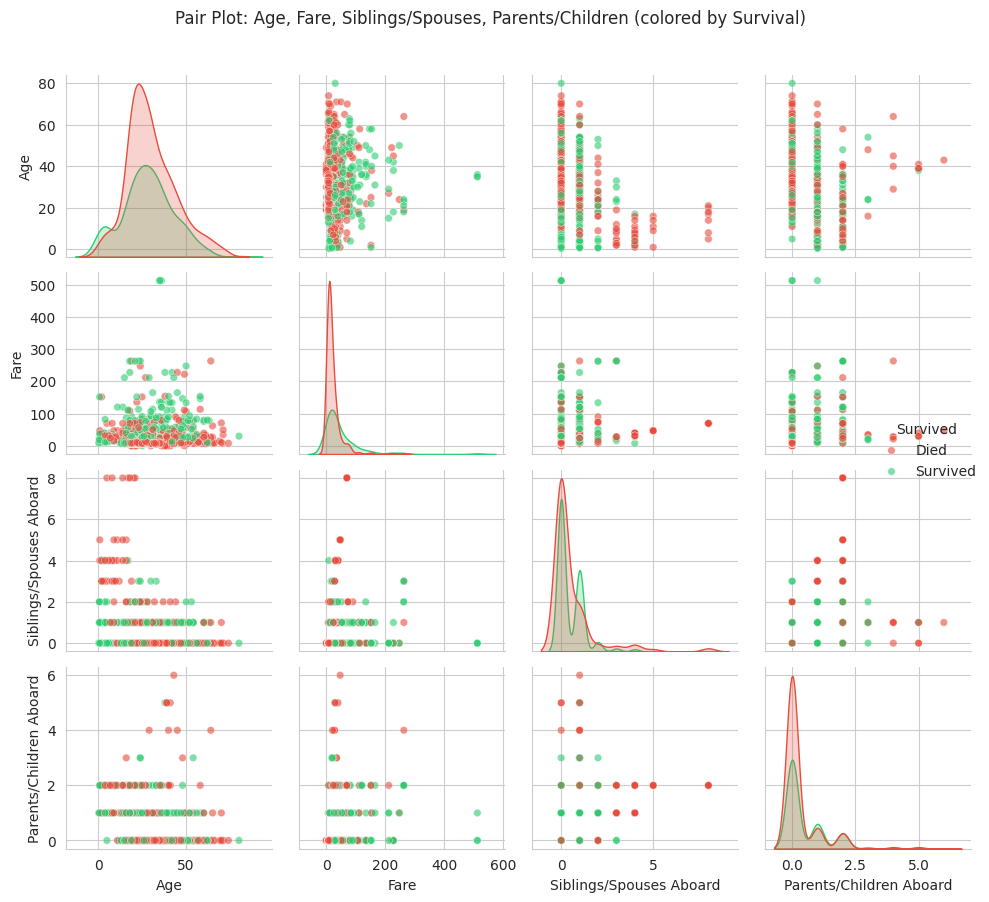

In [33]:
print("\n" + "=" * 60)
print("TASK 7: VISUALIZATIONS")
print("=" * 60)

# Create a histogram of passenger ages
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Histogram of Passenger Ages', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('histogram_passenger_ages.png', dpi=150)
plt.show()

# Create a bar plot of survival rates by passenger class
survival_by_class = df.groupby('PclassCategory')['Survived'].mean().reindex(['First', 'Second', 'Third'])

plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(survival_by_class.index, survival_by_class.values, color=colors, edgecolor='black', alpha=0.8)
plt.title('Survival Rates by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
for bar, val in zip(bars, survival_by_class.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2%}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bar_survival_by_class.png', dpi=150)
plt.show()

# Create a heatmap of correlation between numerical features
plt.figure(figsize=(10, 8))
numerical_cols = ['Survived', 'Pclass', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare', 'Family']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=150)
plt.show()

# Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
pairplot_df = df[['Age', 'Fare', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Survived']].copy()
pairplot_df['Survived'] = pairplot_df['Survived'].map({0: 'Died', 1: 'Survived'})

g = sns.pairplot(pairplot_df, hue='Survived', palette={'Died': '#e74c3c', 'Survived': '#2ecc71'},
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30}, height=2.2)
g.fig.suptitle('Pair Plot: Age, Fare, Siblings/Spouses, Parents/Children (colored by Survival)',
               y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('pairplot_survived.png', dpi=150)
plt.show()

## Analyze Survival Rates

In [34]:
print("\n" + "=" * 60)
print("TASK 8: ANALYZE SURVIVAL RATES")
print("=" * 60)

# Calculate and display survival rates by sex
survival_by_sex = df.groupby('Sex')['Survived'].agg(['mean', 'sum', 'count'])
survival_by_sex.columns = ['Survival_Rate', 'Survivors', 'Total']
print("\n--- Survival rates by sex ---")
print(survival_by_sex.round(4))

# Calculate and display survival rates by passenger class
survival_by_class = df.groupby('PclassCategory')['Survived'].agg(['mean', 'sum', 'count'])
survival_by_class.columns = ['Survival_Rate', 'Survivors', 'Total']
print("\n--- Survival rates by passenger class ---")
print(survival_by_class.reindex(['First', 'Second', 'Third']).round(4))



TASK 8: ANALYZE SURVIVAL RATES

--- Survival rates by sex ---
        Survival_Rate  Survivors  Total
Sex                                    
female         0.7420        233    314
male           0.1902        109    573

--- Survival rates by passenger class ---
                Survival_Rate  Survivors  Total
PclassCategory                                 
First                  0.6296        136    216
Second                 0.4728         87    184
Third                  0.2444        119    487


##Analyze Age Distribution


TASK 9: AGE DISTRIBUTION ANALYSIS


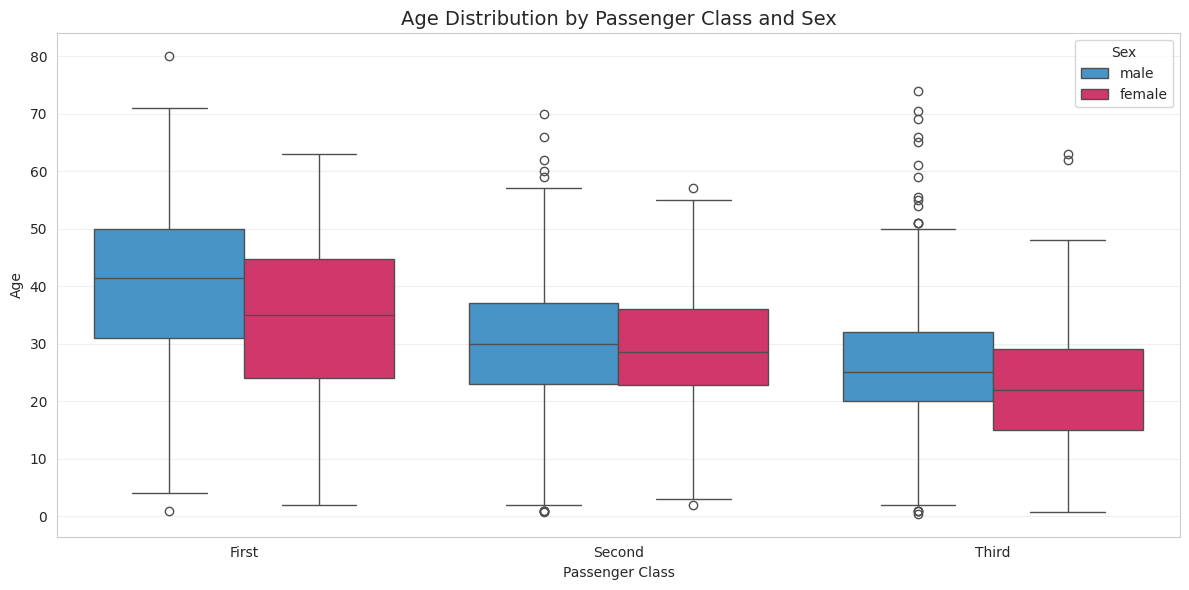

In [35]:
print("\n" + "=" * 60)
print("TASK 9: AGE DISTRIBUTION ANALYSIS")
print("=" * 60)

# Create a box plot of age distribution by passenger class and sex
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='PclassCategory', y='Age', hue='Sex',
            order=['First', 'Second', 'Third'],
            palette={'male': '#3498db', 'female': '#e91e63'})
plt.title('Age Distribution by Passenger Class and Sex', fontsize=14)
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.legend(title='Sex', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_age_distribution.png', dpi=150)
plt.show()


##Analyze Fare Distribution


TASK 10: FARE DISTRIBUTION ANALYSIS


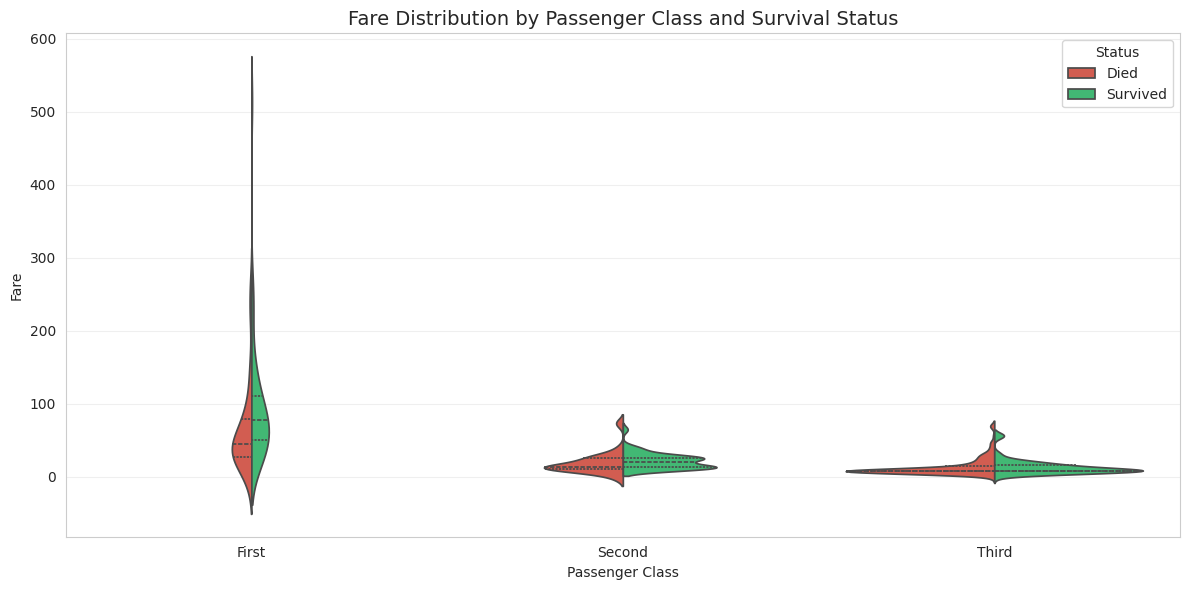


EDA tasks completed.


In [36]:
print("\n" + "=" * 60)
print("TASK 10: FARE DISTRIBUTION ANALYSIS")
print("=" * 60)

# Create a violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(12, 6))
df['SurvivedLabel'] = df['Survived'].map({0: 'Died', 1: 'Survived'})

sns.violinplot(data=df, x='PclassCategory', y='Fare', hue='SurvivedLabel',
               order=['First', 'Second', 'Third'],
               palette={'Died': '#e74c3c', 'Survived': '#2ecc71'},
               split=True, inner='quart')
plt.title('Fare Distribution by Passenger Class and Survival Status', fontsize=14)
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.legend(title='Status', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('violinplot_fare_distribution.png', dpi=150)
plt.show()

print("\nEDA tasks completed.")